In this notebook, we will be working through [Let's Build the GPT Tokenizer](https://www.youtube.com/watch?v=zduSFxRajkE) by Andrej Karpathy. This is the eighth video in the **Neural Networks: Zero to Hero** series.

In [lesson 7](../lesson_7_gpt_from_scratch/gpt.ipynb), we built a GPT from scratch — but we used the simplest possible tokenization: map each unique character in the Shakespeare dataset to an integer. That gave us a vocabulary of just 65 tokens. We explicitly noted this was a massive simplification, and that production LLMs use something far more sophisticated. This lesson fills in that missing piece.

**The core idea:** tokenization is the process that converts raw text into a sequence of integer token IDs *before* the model ever sees it. It is the very first step in the LLM pipeline, and it has far-reaching consequences — from whether a model can spell correctly, to how well it handles non-English languages, to why arithmetic is surprisingly hard for LLMs. Many behaviors people attribute to models "being dumb" are actually **tokenization artifacts**.

We'll build a complete Byte Pair Encoding (BPE) tokenizer from scratch, incrementally improving it at each step as we discover limitations. By the end, our tokenizer will be architecturally identical to what GPT-2 and GPT-4 use — differing only in scale (vocabulary size and training data) and implementation language (our Python vs. OpenAI's Rust-based `tiktoken`).

In [1]:
import tiktoken
import regex  # not `re` — we need Unicode property escapes (\p{L}, \p{N}) that only `regex` supports
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline

# Section 1: Starting Where We Left Off — Character-Level Tokenization

Recall that in [lesson 7](../lesson_7_gpt_from_scratch/gpt.ipynb) we used the simplest possible tokenization strategy: scan through the dataset, collect every unique character, and assign each one an integer ID. For the tiny Shakespeare dataset, this gave us 65 tokens — the 26 lowercase letters, 26 uppercase letters, some punctuation, spaces, and newlines.

Let's reproduce that tokenizer and then systematically stress-test it to understand its limitations.

In [2]:
# The same Shakespeare excerpt we've been working with
shakespeare = """First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge."""

# Character-level tokenizer from lesson 7
chars = sorted(list(set(shakespeare)))
char_vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encode_char = lambda s: [stoi[c] for c in s]
decode_char = lambda l: ''.join([itos[i] for i in l])

char_tokens = encode_char(shakespeare)
print(f"Vocabulary: {char_vocab_size} unique characters")
print(f"Characters: {repr(''.join(chars))}")
print(f"\nEncoded length: {len(char_tokens)} tokens")
print(f"First 30 tokens: {char_tokens[:30]}")
print(f"Decoded back:    '{decode_char(char_tokens[:30])}'")

Vocabulary: 46 unique characters
Characters: "\n !',.:;?ABCFILMNORSWYabcdefghijklmnoprstuvwyz"

Encoded length: 998 tokens
First 30 tokens: [12, 30, 38, 39, 40, 1, 11, 30, 40, 30, 45, 26, 35, 6, 0, 10, 26, 27, 36, 38, 26, 1, 43, 26, 1, 37, 38, 36, 24, 26]
Decoded back:    'First Citizen:
Before we proce'


This works perfectly for our toy Shakespeare model. Every character maps cleanly to a token ID, and we can encode and decode losslessly. But what happens when we try to handle real-world text? Let's throw some challenges at our character-level tokenizer.

In [3]:
# What happens when we encounter characters outside our vocabulary?
test_texts = [
    "Hello! How's the weather today? 😀",
    "안녕하세요 (Korean greeting)",
    "Café, naïve, résumé",
    "The price is €50 or ¥6000",
    "def fibonacci(n):\n    return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)",
]

for text in test_texts:
    try:
        tokens = encode_char(text)
        print(f"OK   '{text[:50]}' -> {len(tokens)} tokens")
    except KeyError as e:
        print(f"FAIL '{text[:50]}' -> KeyError: character {e} not in vocabulary")

FAIL 'Hello! How's the weather today? 😀' -> KeyError: character 'H' not in vocabulary
FAIL '안녕하세요 (Korean greeting)' -> KeyError: character '안' not in vocabulary
FAIL 'Café, naïve, résumé' -> KeyError: character 'é' not in vocabulary
FAIL 'The price is €50 or ¥6000' -> KeyError: character 'T' not in vocabulary
FAIL 'def fibonacci(n):
    return n if n <= 1 else fibo' -> KeyError: character '(' not in vocabulary


**The first problem: limited coverage.** Our character-level tokenizer only knows the 52 characters that appeared in the Shakespeare excerpt. Emojis, Korean characters, accented letters, currency symbols — all produce `KeyError`. Real-world text contains thousands of unique characters across different scripts.

We could expand the vocabulary to include *all* of Unicode — over 150,000 characters and growing. But that creates a different problem...

In [4]:
# What if we built a "full Unicode" character tokenizer?
multilingual_corpus = """English: The quick brown fox jumps over the lazy dog.
Korean: 빠른 갈색 여우가 게으른 개를 뛰어넘습니다.
Chinese: 敏捷的棕色狐狸跳过了懒惰的狗。
Japanese: 素早い茶色の狐が怠惰な犬を飛び越えます。
Arabic: الثعلب البني السريع يقفز فوق الكلب الكسول.
Hindi: तेज़ भूरी लोमड़ी आलसी कुत्ते के ऊपर कूदती है।
Thai: สุนัขจิ้งจอกสีน้ำตาลกระโดดข้ามสุนัขขี้เกียจ
Emoji: 🦊💨🐕💤 The fox 🏃 over the dog 😴
Code: def f(x): return x ** 2 + 3 * x - 7  # quadratic
Math: ∀x ∈ ℝ: x² ≥ 0, ∫₀¹ x dx = ½"""

unique_chars = sorted(set(multilingual_corpus))
print(f"Unique characters in this small corpus: {len(unique_chars)}")
print(f"For reference, Unicode 15.1 defines ~150,000 characters")
print(f"\nVocab size needed for full Unicode coverage: ~150,000+")
print(f"That means an embedding table of 150,000 × d_model parameters")
print(f"At d_model=768 (GPT-2 size): {150_000 * 768:,} parameters just for embeddings")

Unique characters in this small corpus: 172
For reference, Unicode 15.1 defines ~150,000 characters

Vocab size needed for full Unicode coverage: ~150,000+
That means an embedding table of 150,000 × d_model parameters
At d_model=768 (GPT-2 size): 115,200,000 parameters just for embeddings


**The second problem: sequence length.** Even if we could handle all characters, character-level tokenization creates very long sequences. Each character is one token, so a 1000-word document might produce 5000+ tokens. This matters because self-attention — the core mechanism in Transformers — scales as $O(T^2)$ where $T$ is the sequence length. Doubling the sequence length **quadruples** the computation.

Let's see how dramatic this difference is compared to what production LLMs use.

In [5]:
# Compare character-level token counts vs production tokenizers
enc_gpt4 = tiktoken.get_encoding("cl100k_base")  # GPT-4's tokenizer

char_count = len(shakespeare)
gpt4_count = len(enc_gpt4.encode(shakespeare))

print(f"Shakespeare excerpt ({len(shakespeare.split())} words):")
print(f"  Character-level: {char_count} tokens (vocab size: {char_vocab_size})")
print(f"  GPT-4 (BPE):     {gpt4_count} tokens (vocab size: {enc_gpt4.n_vocab:,})")
print(f"  Ratio:           {char_count / gpt4_count:.1f}x longer with character-level")
print(f"\nSince attention is O(T²):")
print(f"  Character-level attention cost: ~{char_count**2:,}")
print(f"  GPT-4 attention cost:           ~{gpt4_count**2:,}")
print(f"  Character-level is ~{(char_count/gpt4_count)**2:.0f}x more expensive")

Shakespeare excerpt (175 words):
  Character-level: 998 tokens (vocab size: 46)
  GPT-4 (BPE):     253 tokens (vocab size: 100,277)
  Ratio:           3.9x longer with character-level

Since attention is O(T²):
  Character-level attention cost: ~996,004
  GPT-4 attention cost:           ~64,009
  Character-level is ~16x more expensive


**The tokenization tradeoff.** There are three broad strategies, each with different trade-offs:

| Strategy | Vocab Size | Sequence Length | Tradeoff |
| :--- | :--- | :--- | :--- |
| **Character-level** | ~65–256 | Very long | Tiny embedding table, but sequences are very long — attention cost explodes |
| **Subword (BPE)** | ~30K–100K | Moderate | Best balance — common words become single tokens, rare words split into pieces |
| **Word-level** | ~500K+ | Short | Short sequences, but huge embedding table and most tokens are rarely seen |

Every modern LLM (GPT-2, GPT-4, LLaMA, Mistral, Claude) uses **subword tokenization via Byte Pair Encoding (BPE)**. It finds the sweet spot: sequences are short enough for efficient attention, and the vocabulary is small enough for a manageable embedding table.

But to understand how BPE works, we first need to understand how text becomes bytes — the layer *below* tokenization.

# Section 2: Unicode & UTF-8 — Text as Bytes

Before we can build a better tokenizer, we need to understand how characters are represented as numbers at the lowest level. There are two key concepts:

- **Unicode** is a universal catalog that assigns a unique integer (called a **code point**) to every character in every writing system — over 150,000 characters as of Unicode 15.1. It covers Latin, Chinese, Arabic, Korean, emoji, mathematical symbols, and much more.
- **UTF-8** is the most common **encoding** — the scheme that maps Unicode code points to actual bytes in memory. It uses a variable-length encoding: 1 to 4 bytes per character.

Understanding UTF-8 is essential because BPE operates on **bytes**, not characters.

## Unicode Code Points

Every character has a unique integer code point. Python's `ord()` function returns it. These code points range from 0 (the null character) to over 1 million, though only ~150,000 are currently assigned.

In [6]:
# Unicode code points: every character has a unique integer
examples = [
    ('A', 'Latin uppercase'),
    ('a', 'Latin lowercase'),
    ('0', 'Digit'),
    (' ', 'Space'),
    ('é', 'Accented Latin'),
    ('ñ', 'Spanish'),
    ('€', 'Currency symbol'),
    ('안', 'Korean'),
    ('你', 'Chinese'),
    ('😀', 'Emoji'),
    ('🎉', 'Emoji'),
]

for char, desc in examples:
    print(f"  ord('{char}') = {ord(char):>7,}  (U+{ord(char):04X})  — {desc}")

  ord('A') =      65  (U+0041)  — Latin uppercase
  ord('a') =      97  (U+0061)  — Latin lowercase
  ord('0') =      48  (U+0030)  — Digit
  ord(' ') =      32  (U+0020)  — Space
  ord('é') =     233  (U+00E9)  — Accented Latin
  ord('ñ') =     241  (U+00F1)  — Spanish
  ord('€') =   8,364  (U+20AC)  — Currency symbol
  ord('안') =  50,504  (U+C548)  — Korean
  ord('你') =  20,320  (U+4F60)  — Chinese
  ord('😀') = 128,512  (U+1F600)  — Emoji
  ord('🎉') = 127,881  (U+1F389)  — Emoji


## UTF-8: Variable-Length Byte Encoding

Unicode gives every character a code point, but code points can be huge numbers (emoji are above 100,000). We need a compact way to store them as bytes. **UTF-8** does this with a clever variable-length scheme:

| Bytes | Code Point Range | Bit Pattern | Examples |
| :---: | :--- | :--- | :--- |
| 1 | U+0000 to U+007F | `0xxxxxxx` | ASCII: `A`, `z`, `0`, `!`, space |
| 2 | U+0080 to U+07FF | `110xxxxx 10xxxxxx` | Latin extended: `ñ`, `ü`, `é` |
| 3 | U+0800 to U+FFFF | `1110xxxx 10xxxxxx 10xxxxxx` | CJK, Korean: `你`, `안`, `€` |
| 4 | U+10000 to U+10FFFF | `11110xxx 10xxxxxx 10xxxxxx 10xxxxxx` | Emoji: `😀`, `🎉` |

The critical implication: **ASCII characters (English letters, digits, basic punctuation) use exactly 1 byte, while everything else uses more.** This means non-English text is literally longer at the byte level — a fact that will come back to haunt us when we look at LLM performance across languages.

In [7]:
# UTF-8 in action: text.encode('utf-8') converts to bytes
examples = [
    ("English",  "Hello"),
    ("Accented", "café"),
    ("Korean",   "안녕"),
    ("Chinese",  "你好"),
    ("Arabic",   "مرحبا"),
    ("Hindi",    "नमस्ते"),
    ("Emoji",    "😀🎉"),
]

for name, text in examples:
    encoded = text.encode("utf-8")
    print(f"{name:10s} '{text}' -> {list(encoded)}")
    print(f"{'':10s} {len(text)} chars, {len(encoded)} bytes ({len(encoded)/len(text):.1f} bytes/char)")
    print()

English    'Hello' -> [72, 101, 108, 108, 111]
           5 chars, 5 bytes (1.0 bytes/char)

Accented   'café' -> [99, 97, 102, 195, 169]
           4 chars, 5 bytes (1.2 bytes/char)

Korean     '안녕' -> [236, 149, 136, 235, 133, 149]
           2 chars, 6 bytes (3.0 bytes/char)

Chinese    '你好' -> [228, 189, 160, 229, 165, 189]
           2 chars, 6 bytes (3.0 bytes/char)

Arabic     'مرحبا' -> [217, 133, 216, 177, 216, 173, 216, 168, 216, 167]
           5 chars, 10 bytes (2.0 bytes/char)

Hindi      'नमस्ते' -> [224, 164, 168, 224, 164, 174, 224, 164, 184, 224, 165, 141, 224, 164, 164, 224, 165, 135]
           6 chars, 18 bytes (3.0 bytes/char)

Emoji      '😀🎉' -> [240, 159, 152, 128, 240, 159, 142, 137]
           2 chars, 8 bytes (4.0 bytes/char)



## The Base Vocabulary: 256 Raw Bytes

Here is the key insight for tokenization: if we convert *any* text to UTF-8 bytes, we get a sequence of integers in the range **[0, 255]**. That means **256 possible byte values form a universal base vocabulary** — it can represent any text in any language, any emoji, any symbol. There is no "unknown token" problem.

The downside: one token per byte means even longer sequences than character-level tokenization, especially for non-ASCII text.

In [8]:
# Raw byte tokenization: universal but verbose
text = "Hello world! 안녕하세요 😀"
raw_bytes = text.encode("utf-8")
byte_tokens = list(raw_bytes)

print(f"Text:        '{text}'")
print(f"Characters:  {len(text)}")
print(f"UTF-8 bytes: {len(byte_tokens)}")
print(f"Byte tokens: {byte_tokens}")
print(f"\nThe Korean '안녕하세요' is 5 characters but {len('안녕하세요'.encode('utf-8'))} bytes")
print(f"The emoji '😀' is 1 character but {len('😀'.encode('utf-8'))} bytes")

Text:        'Hello world! 안녕하세요 😀'
Characters:  20
UTF-8 bytes: 33
Byte tokens: [72, 101, 108, 108, 111, 32, 119, 111, 114, 108, 100, 33, 32, 236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 240, 159, 152, 128]

The Korean '안녕하세요' is 5 characters but 15 bytes
The emoji '😀' is 1 character but 4 bytes


So raw byte tokenization solves the **coverage** problem — any text, any language, any emoji maps cleanly to a sequence of tokens in [0, 255]. But it makes the **sequence length** problem even worse. The Korean greeting alone went from 5 characters to 15 bytes. For a Transformer with $O(T^2)$ attention, this is very expensive.

We need a way to **compress** common byte patterns into single tokens, reducing the sequence length while keeping the universal coverage of bytes. This is exactly what Byte Pair Encoding does.

# Section 3: Byte Pair Encoding (BPE)

BPE was originally a **data compression** algorithm (Gage, 1994). The idea is beautifully simple:

1. Start with a sequence of symbols (in our case, raw bytes)
2. Count all adjacent pairs
3. Replace every occurrence of the most frequent pair with a new symbol
4. Repeat until you reach the desired vocabulary size

Sennrich et al. (2016) adapted BPE for NLP tokenization in ["Neural Machine Translation of Rare Words with Subword Units"](https://arxiv.org/abs/1508.07909), and it has been the standard approach ever since. GPT-2, GPT-3, GPT-4, LLaMA, Mistral — every major modern LLM uses BPE.

Let's build it step by step.

## Step 1: Counting Pair Frequencies

Before we can merge anything, we need to know which pairs of adjacent tokens appear most often. We scan through the list once with `zip(ids, ids[1:])` — a clean Python idiom that creates a sliding window of size 2.

In [9]:
def get_stats(ids):
    """Count frequency of consecutive pairs in a list of token IDs."""
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

# Try it on a simple toy example first
text = "aaabdaaabac"
tokens = list(text.encode("utf-8"))
print(f"Text:   '{text}'")
print(f"Tokens: {tokens}")
print(f"  (these are ASCII values: {', '.join(f'{t}={chr(t)!r}' for t in sorted(set(tokens)))})")
print()

stats = get_stats(tokens)
print("Pair frequencies (sorted by count):")
for pair, count in sorted(stats.items(), key=lambda x: -x[1]):
    print(f"  ({pair[0]}, {pair[1]}) = ('{chr(pair[0])}', '{chr(pair[1])}') -> count={count}")

Text:   'aaabdaaabac'
Tokens: [97, 97, 97, 98, 100, 97, 97, 97, 98, 97, 99]
  (these are ASCII values: 97='a', 98='b', 99='c', 100='d')

Pair frequencies (sorted by count):
  (97, 97) = ('a', 'a') -> count=4
  (97, 98) = ('a', 'b') -> count=2
  (98, 100) = ('b', 'd') -> count=1
  (100, 97) = ('d', 'a') -> count=1
  (98, 97) = ('b', 'a') -> count=1
  (97, 99) = ('a', 'c') -> count=1


## Step 2: Merging the Top Pair

Now we take the most frequent pair and replace every consecutive occurrence with a **new token ID**. Since bytes use IDs 0–255, our new merged tokens start at 256.

In [10]:
def merge(ids, pair, idx):
    """Replace all consecutive occurrences of pair with new token idx."""
    newids = []
    i = 0
    while i < len(ids):
        # if we're not at the last position AND the pair matches, merge
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids

# Merge the most frequent pair from our toy example
top_pair = max(stats, key=stats.get)
print(f"Most frequent pair: ({top_pair[0]}, {top_pair[1]}) = ('{chr(top_pair[0])}', '{chr(top_pair[1])}')")
print(f"Count: {stats[top_pair]}")
print()

new_tokens = merge(tokens, top_pair, 256)
print(f"Before: {tokens}  (length {len(tokens)})")
print(f"After:  {new_tokens}  (length {len(new_tokens)})")
print(f"\nToken 256 now represents the byte pair ('{chr(top_pair[0])}', '{chr(top_pair[1])}') = '{chr(top_pair[0])}{chr(top_pair[1])}'")

Most frequent pair: (97, 97) = ('a', 'a')
Count: 4

Before: [97, 97, 97, 98, 100, 97, 97, 97, 98, 97, 99]  (length 11)
After:  [256, 97, 98, 100, 256, 97, 98, 97, 99]  (length 9)

Token 256 now represents the byte pair ('a', 'a') = 'aa'


## Step 3: The Training Loop

We simply repeat steps 1 and 2: count pairs → merge the most frequent → count again → merge again. Each iteration adds exactly one new token to the vocabulary, so the number of merges equals `desired_vocab_size - 256`.

Let's run 3 merges on our toy example to see the full loop in action.

In [11]:
# Full BPE training loop on the toy example
tokens = list(text.encode("utf-8"))
num_merges = 3

print(f"Starting tokens: {tokens}  ('{text}')")
print(f"Starting length: {len(tokens)}")
print()

merges = {}  # (pair) -> new_token_id
for i in range(num_merges):
    stats = get_stats(tokens)
    top_pair = max(stats, key=stats.get)
    idx = 256 + i
    tokens = merge(tokens, top_pair, idx)
    merges[top_pair] = idx
    print(f"Merge {i+1}: ({top_pair[0]:>3d}, {top_pair[1]:>3d}) -> token {idx}  |  length: {len(tokens)}  |  tokens: {tokens}")

original_len = len(list(text.encode("utf-8")))
print(f"\nCompression: {original_len} -> {len(tokens)} tokens ({original_len / len(tokens):.2f}x)")

Starting tokens: [97, 97, 97, 98, 100, 97, 97, 97, 98, 97, 99]  ('aaabdaaabac')
Starting length: 11

Merge 1: ( 97,  97) -> token 256  |  length: 9  |  tokens: [256, 97, 98, 100, 256, 97, 98, 97, 99]
Merge 2: (256,  97) -> token 257  |  length: 7  |  tokens: [257, 98, 100, 257, 98, 97, 99]
Merge 3: (257,  98) -> token 258  |  length: 5  |  tokens: [258, 100, 258, 97, 99]

Compression: 11 -> 5 tokens (2.20x)


## Building the Vocabulary

During training, we record each merge in a dictionary: `(pair) -> new_token_id`. This merge table is all we need to reconstruct what each new token represents. Token 256 is the concatenation of the bytes from its pair. Token 257 might contain token 256 plus another byte — so tokens can **recursively contain** other merged tokens.

In [12]:
# Build the vocabulary from our merge table
vocab = {idx: bytes([idx]) for idx in range(256)}  # base vocab: single bytes
for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]

print("Learned vocabulary (new tokens only):")
for idx in range(256, 256 + num_merges):
    raw = vocab[idx]
    decoded = raw.decode('utf-8', errors='replace')
    print(f"  token {idx}: bytes={list(raw)} -> '{decoded}'")

Learned vocabulary (new tokens only):
  token 256: bytes=[97, 97] -> 'aa'
  token 257: bytes=[97, 97, 97] -> 'aaa'
  token 258: bytes=[97, 97, 97, 98] -> 'aaab'


## BPE on Real Text

The toy example builds intuition, but let's see what BPE discovers on actual English text. The first merges should capture the most common byte patterns in the language — frequent character bigrams and trigrams.

In [13]:
# BPE training on real English text
shakespeare_bytes = list(shakespeare.encode("utf-8"))
print(f"Training text: {len(shakespeare_bytes)} bytes")
print()

num_merges = 20
tokens = list(shakespeare_bytes)
merges = {}

for i in range(num_merges):
    stats = get_stats(tokens)
    if not stats:
        break
    top_pair = max(stats, key=stats.get)
    idx = 256 + i
    tokens = merge(tokens, top_pair, idx)
    merges[top_pair] = idx

# Build vocab and display the learned merges
vocab = {idx: bytes([idx]) for idx in range(256)}
for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]

print(f"After {num_merges} merges: {len(shakespeare_bytes)} bytes -> {len(tokens)} tokens")
print(f"Compression ratio: {len(shakespeare_bytes) / len(tokens):.2f}x")
print(f"\nLearned merges (in order):")
for (p0, p1), idx in merges.items():
    merged_str = vocab[idx].decode('utf-8', errors='replace')
    left_str = vocab[p0].decode('utf-8', errors='replace')
    right_str = vocab[p1].decode('utf-8', errors='replace')
    print(f"  {idx}: {repr(left_str):>6s} + {repr(right_str):<6s} -> {repr(merged_str)}")

Training text: 998 bytes

After 20 merges: 998 bytes -> 762 tokens
Compression ratio: 1.31x

Learned merges (in order):
  256:    'e' + ' '    -> 'e '
  257:    't' + 'h'    -> 'th'
  258:    't' + ' '    -> 't '
  259:    's' + ' '    -> 's '
  260:    ',' + ' '    -> ', '
  261:    'e' + 'n'    -> 'en'
  262:    'i' + 't'    -> 'it'
  263:    'r' + ' '    -> 'r '
  264:    ':' + '\n'   -> ':\n'
  265:    'd' + ' '    -> 'd '
  266:    'a' + 'n'    -> 'an'
  267:   '\n' + '\n'   -> '\n\n'
  268:    'o' + 'u'    -> 'ou'
  269:   'it' + 'i'    -> 'iti'
  270:  'iti' + 'z'    -> 'itiz'
  271: 'itiz' + 'en'   -> 'itizen'
  272:    'r' + 'e'    -> 're'
  273:    'i' + 'r'    -> 'ir'
  274:   'ir' + 's'    -> 'irs'
  275:   'th' + 'e'    -> 'the'


Notice the pattern: the first merges capture the most frequent bigrams in English text. Space followed by common starting letters (`' t'`, `' a'`, `' o'`) merge early because words like "the", "to", "that", "are", "of", "on" are extremely common. Then common within-word patterns like `'th'`, `'he'`, `'er'` follow.

BPE is discovering **language structure** purely from byte-level frequency statistics, with zero linguistic knowledge built in. This is part of what makes it so elegant and universal — it works for any language, any script, without any language-specific rules.

## The BasicTokenizer

Let's package everything into a proper tokenizer class with three methods:
- `train(text, vocab_size)` — learn BPE merges from text
- `encode(text)` — convert text to token IDs
- `decode(ids)` — convert token IDs back to text

The `encode` step has a subtle but critical detail that we need to get right...

In [14]:
class BasicTokenizer:
    """Byte Pair Encoding tokenizer — no regex pre-tokenization."""

    def __init__(self):
        self.merges = {}   # (int, int) -> int
        self.vocab = {}    # int -> bytes

    def train(self, text, vocab_size):
        """Train BPE on text to build a vocabulary of the given size."""
        assert vocab_size >= 256, "Vocab size must be >= 256 (base byte tokens)"
        num_merges = vocab_size - 256

        tokens = list(text.encode("utf-8"))
        merges = {}

        for i in range(num_merges):
            stats = get_stats(tokens)
            if not stats:
                break
            top_pair = max(stats, key=stats.get)
            idx = 256 + i
            tokens = merge(tokens, top_pair, idx)
            merges[top_pair] = idx

        # Build vocab: each token maps to its byte representation
        self.merges = merges
        self.vocab = {idx: bytes([idx]) for idx in range(256)}
        for (p0, p1), idx in merges.items():
            self.vocab[idx] = self.vocab[p0] + self.vocab[p1]

    def encode(self, text):
        """Encode text into a list of token IDs."""
        tokens = list(text.encode("utf-8"))
        while len(tokens) >= 2:
            stats = get_stats(tokens)
            # Find the pair with the lowest merge index (earliest learned merge)
            pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
            if pair not in self.merges:
                break  # no more applicable merges
            idx = self.merges[pair]
            tokens = merge(tokens, pair, idx)
        return tokens

    def decode(self, ids):
        """Decode a list of token IDs back into text."""
        raw_bytes = b"".join(self.vocab[idx] for idx in ids)
        return raw_bytes.decode("utf-8", errors="replace")

**A critical detail in `encode()`.** Notice that we use `min(stats, key=lambda p: self.merges.get(p, float("inf")))` — this finds the pair whose merge was **learned earliest** during training (lowest token index), *not* the most frequent pair in the current text.

Why does this matter? Consider a text where the pair `(101, 32)` appears 10 times and `(116, 104)` appears 5 times. If `(116, 104)` was merge #1 during training and `(101, 32)` was merge #5, we apply `(116, 104)` first — because that's the order the tokenizer learned them.

This ensures **deterministic encoding**: the same text always produces the same tokens, regardless of what other text surrounds it. Without this ordering, encoding would depend on the frequency distribution of the specific input, giving different results for the same substring in different contexts.

In [15]:
# Train and test the BasicTokenizer
basic_tok = BasicTokenizer()
basic_tok.train(shakespeare, vocab_size=276)  # 256 base + 20 merges

test_text = "Speak, speak."
encoded = basic_tok.encode(test_text)
decoded = basic_tok.decode(encoded)

print(f"Text:    '{test_text}'")
print(f"Encoded: {encoded} ({len(encoded)} tokens)")
print(f"Decoded: '{decoded}'")
print(f"Lossless round-trip: {test_text == decoded}")

Text:    'Speak, speak.'
Encoded: [83, 112, 101, 97, 107, 260, 115, 112, 101, 97, 107, 46] (12 tokens)
Decoded: 'Speak, speak.'
Lossless round-trip: True


In [16]:
# Verify lossless round-trip on the full training text
encoded_full = basic_tok.encode(shakespeare)
decoded_full = basic_tok.decode(encoded_full)

print(f"Full text round-trip match: {shakespeare == decoded_full}")
print(f"Original bytes: {len(shakespeare.encode('utf-8'))}")
print(f"BPE tokens:     {len(encoded_full)}")
print(f"Compression:    {len(shakespeare.encode('utf-8')) / len(encoded_full):.2f}x")

Full text round-trip match: True
Original bytes: 998
BPE tokens:     762
Compression:    1.31x


## Visualizing Compression vs. Vocabulary Size

Each merge adds one token to the vocabulary and reduces the total token count. But the returns are diminishing — the first few merges compress the most common patterns and provide the biggest wins, while later merges catch increasingly rare patterns.

Corpus size: 1,115,394 bytes
vocab_size=  256 (  0 merges): 1115394 tokens, compression=1.00x
vocab_size=  276 ( 20 merges): 882737 tokens, compression=1.26x
vocab_size=  300 ( 44 merges): 788667 tokens, compression=1.41x
vocab_size=  350 ( 94 merges): 695868 tokens, compression=1.60x
vocab_size=  400 (144 merges): 640353 tokens, compression=1.74x
vocab_size=  500 (244 merges): 574057 tokens, compression=1.94x
vocab_size=  750 (494 merges): 491952 tokens, compression=2.27x
vocab_size= 1000 (744 merges): 447069 tokens, compression=2.49x
vocab_size= 2000 (1744 merges): 361821 tokens, compression=3.08x
vocab_size= 5000 (4744 merges): 280573 tokens, compression=3.98x
vocab_size=10000 (9744 merges): 236232 tokens, compression=4.72x


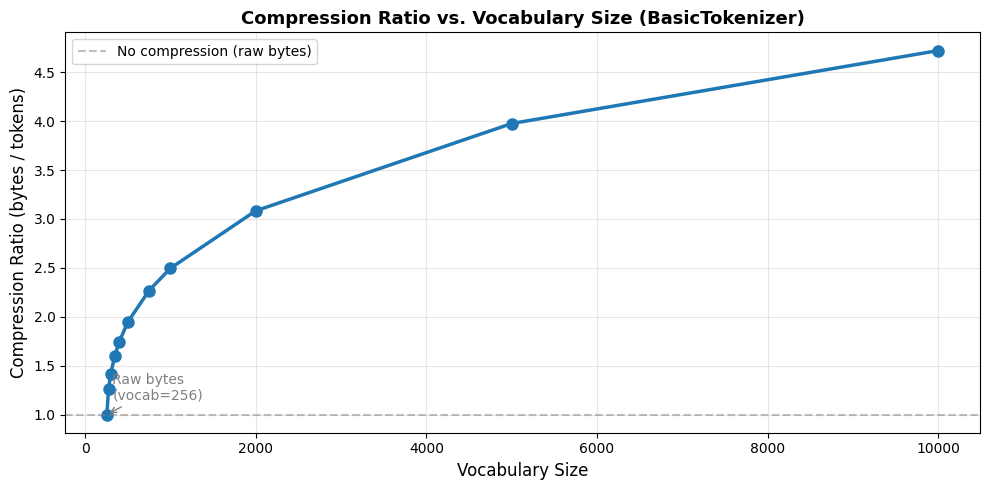

In [43]:
# Train at multiple vocab sizes and measure compression — in parallel
# Our tiny Shakespeare excerpt (~1KB) is too small — BPE memorizes it all in a few
# hundred merges. Use the full tinyshakespeare corpus (~1MB) instead.
import urllib.request
import multiprocessing as mp

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
long_text = urllib.request.urlopen(url).read().decode("utf-8")
n_bytes = len(long_text.encode("utf-8"))
print(f"Corpus size: {n_bytes:,} bytes")

vocab_sizes = [256, 276, 300, 350, 400, 500, 750, 1000, 2000, 5000, 10000]

def train_and_measure(vs):
    tok = BasicTokenizer()
    tok.train(long_text, vocab_size=vs)
    n_tokens = len(tok.encode(long_text))
    ratio = n_bytes / n_tokens
    return vs, n_tokens, ratio

# Each vocab size is independent — train them all in parallel.
# Use fork context so child processes inherit BasicTokenizer, long_text, etc.
ctx = mp.get_context("fork")
with ctx.Pool() as pool:
    results = pool.map(train_and_measure, vocab_sizes)

compression_ratios = []
for vs, n_tokens, ratio in results:
    compression_ratios.append(ratio)
    print(f"vocab_size={vs:5d} ({vs-256:3d} merges): {n_tokens:6d} tokens, compression={ratio:.2f}x")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(vocab_sizes, compression_ratios, "o-", color="#1f77b4", linewidth=2.5, markersize=8)
ax.set_xlabel("Vocabulary Size", fontsize=12)
ax.set_ylabel("Compression Ratio (bytes / tokens)", fontsize=12)
ax.set_title("Compression Ratio vs. Vocabulary Size (BasicTokenizer)", fontsize=13, fontweight="bold")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="No compression (raw bytes)")
ax.annotate("Raw bytes\n(vocab=256)", xy=(256, 1.0), xytext=(320, 1.15),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10, color="gray")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The curve shows clear diminishing returns. Production tokenizers like GPT-2 (50,257 vocab) and GPT-4 (100,277 vocab) operate far to the right of this curve, where each additional merge provides minimal extra compression but adds a row to the embedding table. The optimal vocabulary size balances shorter sequences (good for attention cost) against a larger embedding table (more parameters to train).

Our `BasicTokenizer` implements the full BPE algorithm and achieves lossless compression on any text. **But there's a problem** — one we can only see by looking closely at *what* it's actually learning. Let's inspect the merges more carefully...

# Section 4: The Problem with Naive BPE

Our `BasicTokenizer` treats the entire input text as one flat sequence of bytes. BPE then greedily merges the most frequent adjacent pairs — regardless of where they fall in the text. This means **merges can cross word boundaries**, creating tokens that span the end of one word and the start of the next.

In [18]:
# Train on a text with repetitive structure to expose cross-boundary merges
repetitive_text = "the important thing is the important idea that the important " * 20

basic_tok2 = BasicTokenizer()
basic_tok2.train(repetitive_text, vocab_size=280)  # 24 merges

print("Learned merges:")
for (p0, p1), idx in basic_tok2.merges.items():
    left = basic_tok2.vocab[p0].decode('utf-8', errors='replace')
    right = basic_tok2.vocab[p1].decode('utf-8', errors='replace')
    merged = basic_tok2.vocab[idx].decode('utf-8', errors='replace')
    # Flag cross-word-boundary merges
    flag = " ⚠️ CROSSES WORD BOUNDARY" if ' ' in merged and not merged.startswith(' ') else ""
    print(f"  {idx}: {repr(left):>10s} + {repr(right):<10s} -> {repr(merged)}{flag}")

Learned merges:
  256:        't' + 'h'        -> 'th'
  257:        ' ' + 'i'        -> ' i'
  258:        ' ' + 'th'       -> ' th'
  259:        'e' + ' i'       -> 'e i' ⚠️ CROSSES WORD BOUNDARY
  260:      'e i' + 'm'        -> 'e im' ⚠️ CROSSES WORD BOUNDARY
  261:     'e im' + 'p'        -> 'e imp' ⚠️ CROSSES WORD BOUNDARY
  262:    'e imp' + 'o'        -> 'e impo' ⚠️ CROSSES WORD BOUNDARY
  263:   'e impo' + 'r'        -> 'e impor' ⚠️ CROSSES WORD BOUNDARY
  264:  'e impor' + 't'        -> 'e import' ⚠️ CROSSES WORD BOUNDARY
  265: 'e import' + 'a'        -> 'e importa' ⚠️ CROSSES WORD BOUNDARY
  266: 'e importa' + 'n'        -> 'e importan' ⚠️ CROSSES WORD BOUNDARY
  267: 'e importan' + 't'        -> 'e important' ⚠️ CROSSES WORD BOUNDARY
  268:      ' th' + 'e important' -> ' the important'
  269:      ' th' + 'i'        -> ' thi'
  270:     ' thi' + 'n'        -> ' thin'
  271:    ' thin' + 'g'        -> ' thing'
  272:   ' thing' + ' i'       -> ' thing i'
  273: ' thing i'

**Why this is a problem.** These cross-boundary tokens are problematic for three reasons:

1. **Semantically meaningless** — a token spanning `"t th"` or `"e i"` captures no useful linguistic unit. It's just a frequent byte accident.
2. **Wasteful** — each cross-boundary merge uses a vocabulary slot that could represent a useful subword like `"ing"`, `"tion"`, or `"the"`.
3. **Context-dependent** — whether a word gets a particular tokenization depends on what word comes *before or after* it. This makes the model's job harder because the same word can have different token representations.

Let's see that third problem concretely.

In [19]:
# The same word can tokenize differently depending on context
contexts = [
    "the important thing",
    "an important thing",
    "very important thing",
]

print("Same word 'important' in different contexts:\n")
for ctx in contexts:
    tokens = basic_tok2.encode(ctx)
    decoded_tokens = [basic_tok2.decode([t]) for t in tokens]
    print(f"  '{ctx}'")
    print(f"  -> tokens: {decoded_tokens}")
    print()

Same word 'important' in different contexts:

  'the important thing'
  -> tokens: ['th', 'e important', ' thing']

  'an important thing'
  -> tokens: ['a', 'n', ' i', 'm', 'p', 'o', 'r', 't', 'a', 'n', 't', ' thing']

  'very important thing'
  -> tokens: ['v', 'e', 'r', 'y', ' i', 'm', 'p', 'o', 'r', 't', 'a', 'n', 't', ' thing']



## The Fix: Regex Pre-Tokenization

GPT-2 ([Radford et al., 2019](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)) solved this problem elegantly: **before** running BPE, split the text into chunks using a carefully designed regex pattern. BPE then runs **independently** within each chunk, so merges can never cross chunk boundaries.

The chunks are designed to align with natural linguistic units: words (with their leading space), numbers, punctuation sequences, and whitespace. This prevents the meaningless cross-boundary merges we just saw.

## The GPT-2 Regex Pattern

GPT-2's pattern is dense but carefully designed. Let's break it down piece by piece:

```
'(?:[sdmt]|ll|ve|re)        # contractions: 's, 'd, 'm, 't, 'll, 've, 're
| ?\p{L}+                   # optional space + one or more Unicode letters (words)
| ?\p{N}+                   # optional space + one or more Unicode digits (numbers)
| ?[^\s\p{L}\p{N}]+        # optional space + punctuation/symbols
|\s+(?!\S)                  # trailing whitespace (at end of string)
|\s+                        # any other whitespace
```

| Component | Matches | Examples |
| :--- | :--- | :--- |
| `'(?:[sdmt]\|ll\|ve\|re)` | English contractions | `'s`, `'t`, `'ll`, `'ve`, `'re` |
| `\| ?\p{L}+` | Optional space + letters | ` Hello`, `world`, ` café` |
| `\| ?\p{N}+` | Optional space + digits | ` 123`, `45`, ` 2024` |
| `\| ?[^\s\p{L}\p{N}]+` | Optional space + punctuation | ` !`, `...`, ` —` |
| `\|\s+(?!\S)` | Trailing whitespace | `   ` (at end of text) |
| `\|\s+` | Other whitespace | ` `, `\n` |

**Important:** we use the `regex` module (not Python's built-in `re`) because `\p{L}` (Unicode letter) and `\p{N}` (Unicode digit) are Unicode property escapes that only `regex` supports.

In [20]:
GPT2_SPLIT_PATTERN = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""

text = "Hello world! I'm testing 123 numbers and don't you forget it. 안녕하세요!"
chunks = regex.findall(GPT2_SPLIT_PATTERN, text)

print(f"Text: '{text}'")
print(f"\nChunks ({len(chunks)}):")
for i, chunk in enumerate(chunks):
    print(f"  {i:2d}: {repr(chunk)}")

Text: 'Hello world! I'm testing 123 numbers and don't you forget it. 안녕하세요!'

Chunks (17):
   0: 'Hello'
   1: ' world'
   2: '!'
   3: ' I'
   4: "'m"
   5: ' testing'
   6: ' 123'
   7: ' numbers'
   8: ' and'
   9: ' don'
  10: "'t"
  11: ' you'
  12: ' forget'
  13: ' it'
  14: '.'
  15: ' 안녕하세요'
  16: '!'


Notice what the regex does:

- **Contractions** are split at the apostrophe: `"I"` + `"'m"`, `"don"` + `"'t"` — each piece becomes its own chunk
- **Spaces attach to the following word**: `" world"`, `" testing"`, `" numbers"` — this is why BPE tokens often have a leading space
- **Numbers** stay together as one chunk: `" 123"`
- **Punctuation** separates from words: `"!"`, `"."` get their own chunks
- **Non-Latin scripts** work too: `" 안녕하세요"` is a single chunk

Now BPE will operate *within* each chunk. The merge `(' ', 'w')` can only happen inside `" world"`, never across `"!"` and `" I"`. Cross-boundary merges are impossible.

## Building the RegexTokenizer

We extend our `BasicTokenizer` logic to add pre-tokenization. The key changes:
- **During training**: split text into chunks, convert each chunk to bytes, then count pairs *across all chunks* but merge *within* each chunk independently.
- **During encoding**: split text into chunks, encode each chunk with BPE independently, then concatenate the results.

In [21]:
class RegexTokenizer:
    """BPE tokenizer with regex-based pre-tokenization (GPT-2/GPT-4 style)."""

    def __init__(self, pattern=None):
        self.pattern = pattern or GPT2_SPLIT_PATTERN
        self.compiled_pattern = regex.compile(self.pattern)
        self.merges = {}        # (int, int) -> int
        self.vocab = {}         # int -> bytes
        self.special_tokens = {}          # str -> int
        self.inverse_special_tokens = {}  # int -> str

    def train(self, text, vocab_size):
        """Train BPE with regex pre-tokenization."""
        assert vocab_size >= 256
        num_merges = vocab_size - 256

        # Pre-tokenize: split text into chunks via regex
        chunks = regex.findall(self.compiled_pattern, text)
        chunk_ids = [list(chunk.encode("utf-8")) for chunk in chunks]

        merges = {}
        for i in range(num_merges):
            # Count pairs across ALL chunks
            stats = {}
            for ids in chunk_ids:
                chunk_stats = get_stats(ids)
                for pair, count in chunk_stats.items():
                    stats[pair] = stats.get(pair, 0) + count
            if not stats:
                break
            top_pair = max(stats, key=stats.get)
            idx = 256 + i
            # Merge within each chunk independently
            chunk_ids = [merge(ids, top_pair, idx) for ids in chunk_ids]
            merges[top_pair] = idx

        self.merges = merges
        self.vocab = {idx: bytes([idx]) for idx in range(256)}
        for (p0, p1), idx in merges.items():
            self.vocab[idx] = self.vocab[p0] + self.vocab[p1]

    def _encode_chunk(self, text_bytes):
        """Encode a single pre-tokenized chunk with BPE."""
        tokens = list(text_bytes)
        while len(tokens) >= 2:
            stats = get_stats(tokens)
            pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
            if pair not in self.merges:
                break
            idx = self.merges[pair]
            tokens = merge(tokens, pair, idx)
        return tokens

    def encode(self, text):
        """Encode text with pre-tokenization + BPE."""
        chunks = regex.findall(self.compiled_pattern, text)
        ids = []
        for chunk in chunks:
            chunk_bytes = chunk.encode("utf-8")
            ids.extend(self._encode_chunk(chunk_bytes))
        return ids

    def decode(self, ids):
        """Decode token IDs back to text."""
        raw_bytes = b"".join(self.vocab.get(idx, b"") for idx in ids)
        return raw_bytes.decode("utf-8", errors="replace")

    def register_special_tokens(self, special_tokens):
        """Register special tokens (handled separately from BPE)."""
        self.special_tokens = special_tokens  # str -> int
        self.inverse_special_tokens = {v: k for k, v in special_tokens.items()}

In [22]:
# Train RegexTokenizer and compare with BasicTokenizer
regex_tok = RegexTokenizer(pattern=GPT2_SPLIT_PATTERN)
regex_tok.train(shakespeare, vocab_size=276)

print("RegexTokenizer learned merges:")
for (p0, p1), idx in regex_tok.merges.items():
    left = regex_tok.vocab[p0].decode('utf-8', errors='replace')
    right = regex_tok.vocab[p1].decode('utf-8', errors='replace')
    merged = regex_tok.vocab[idx].decode('utf-8', errors='replace')
    has_space = ' ' in merged and not merged.startswith(' ') and not merged.endswith(' ')
    flag = " ⚠️ CROSS-BOUNDARY" if has_space else ""
    print(f"  {idx}: {repr(left):>8s} + {repr(right):<8s} -> {repr(merged)}{flag}")

RegexTokenizer learned merges:
  256:      ' ' + 't'      -> ' t'
  257:     ' t' + 'h'      -> ' th'
  258:      ' ' + 'a'      -> ' a'
  259:      'i' + 't'      -> 'it'
  260:      'r' + 'e'      -> 're'
  261:      'e' + 'n'      -> 'en'
  262:      ' ' + 'w'      -> ' w'
  263:    ' th' + 'e'      -> ' the'
  264:      'o' + 'u'      -> 'ou'
  265:      'i' + 'r'      -> 'ir'
  266:     'it' + 'i'      -> 'iti'
  267:    'iti' + 'z'      -> 'itiz'
  268:   'itiz' + 'en'     -> 'itizen'
  269:      'i' + 's'      -> 'is'
  270:      'u' + 's'      -> 'us'
  271:      'o' + 'r'      -> 'or'
  272:     'ir' + 's'      -> 'irs'
  273:    'irs' + 't'      -> 'irst'
  274:      ' ' + 'C'      -> ' C'
  275:     ' w' + 'e'      -> ' we'


No more cross-boundary merges. Every token represents a linguistically meaningful subword unit — letter combinations, common prefixes/suffixes, or frequent short words with their leading space.

In [23]:
# Verify: same word now tokenizes consistently regardless of context
regex_tok2 = RegexTokenizer(pattern=GPT2_SPLIT_PATTERN)
regex_tok2.train(repetitive_text, vocab_size=280)

print("RegexTokenizer — 'important' in different contexts:\n")
for ctx in contexts:
    tokens = regex_tok2.encode(ctx)
    decoded_tokens = [regex_tok2.decode([t]) for t in tokens]
    print(f"  '{ctx}'")
    print(f"  -> tokens: {decoded_tokens}")
    print()

RegexTokenizer — 'important' in different contexts:

  'the important thing'
  -> tokens: ['the', ' important', ' thing']

  'an important thing'
  -> tokens: ['a', 'n', ' important', ' thing']

  'very important thing'
  -> tokens: ['v', 'e', 'r', 'y', ' important', ' thing']



## But GPT-2's Pattern Has Limitations

The GPT-2 regex pattern was a big improvement over naive BPE, but over time, two issues were discovered. Let's see them concretely.

In [24]:
# Problem 1: Case-sensitive contractions
text_lower = "I'm happy and she's happy"
text_upper = "I'M HAPPY AND SHE'S HAPPY"

chunks_lower = regex.findall(GPT2_SPLIT_PATTERN, text_lower)
chunks_upper = regex.findall(GPT2_SPLIT_PATTERN, text_upper)

print("GPT-2 pattern — contraction handling:")
print(f"  '{text_lower}' -> {chunks_lower}")
print(f"  '{text_upper}' -> {chunks_upper}")
print()
print("Notice: 'm is correctly split from 'I' in lowercase,")
print("but 'M in uppercase is NOT matched by the contraction rule.")
print("The 'M gets absorbed into 'HAPPY' or split differently.")
print()

# Problem 2: Numbers stay as one chunk
text_nums = "The year 2024 and number 12345 and pi 3.14159"
chunks_nums = regex.findall(GPT2_SPLIT_PATTERN, text_nums)

print("GPT-2 pattern — number handling:")
print(f"  '{text_nums}'")
print(f"  -> {chunks_nums}")
print()
print("Notice: '12345' stays as one chunk. BPE might learn it as one token,")
print("but '12346' would tokenize completely differently. This inconsistency")
print("makes arithmetic very hard for the model.")

GPT-2 pattern — contraction handling:
  'I'm happy and she's happy' -> ['I', "'m", ' happy', ' and', ' she', "'s", ' happy']
  'I'M HAPPY AND SHE'S HAPPY' -> ['I', "'", 'M', ' HAPPY', ' AND', ' SHE', "'", 'S', ' HAPPY']

Notice: 'm is correctly split from 'I' in lowercase,
but 'M in uppercase is NOT matched by the contraction rule.
The 'M gets absorbed into 'HAPPY' or split differently.

GPT-2 pattern — number handling:
  'The year 2024 and number 12345 and pi 3.14159'
  -> ['The', ' year', ' 2024', ' and', ' number', ' 12345', ' and', ' pi', ' 3', '.', '14159']

Notice: '12345' stays as one chunk. BPE might learn it as one token,
but '12346' would tokenize completely differently. This inconsistency
makes arithmetic very hard for the model.


## The GPT-4 Regex Pattern — Fixing the Issues

GPT-4 introduced an improved regex pattern that addresses both problems:

1. **Case-insensitive contractions**: `'(?i:[sdmt]|ll|ve|re)` — the `(?i:...)` flag matches `'M`, `'S`, `'LL` just as well as `'m`, `'s`, `'ll`
2. **Numbers split into 1–3 digit groups**: `\p{N}{1,3}` — forces `12345` into `123` + `45`. This means BPE can learn consistent representations for numbers 0–999, making arithmetic patterns more regular and learnable

Let's compare the two patterns side by side.

In [25]:
GPT4_SPLIT_PATTERN = r"""'(?i:[sdmt]|ll|ve|re)|[^\r\n\p{L}\p{N}]?+\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]++[\r\n]*|\s*[\r\n]|\s+(?!\S)|\s+"""

test_text = "Hello world! I'M testing 12345 and I'm happy don't 안녕하세요"

gpt2_chunks = regex.findall(GPT2_SPLIT_PATTERN, test_text)
gpt4_chunks = regex.findall(GPT4_SPLIT_PATTERN, test_text)

print(f"Text: '{test_text}'\n")
print("GPT-2 chunks:")
for i, c in enumerate(gpt2_chunks):
    print(f"  {i:2d}: {repr(c)}")

print(f"\nGPT-4 chunks:")
for i, c in enumerate(gpt4_chunks):
    print(f"  {i:2d}: {repr(c)}")

print("\n--- Key differences ---")
print("1. GPT-4 correctly splits I'M -> 'I' + '\'M' (case-insensitive)")
print("2. GPT-4 splits 12345 -> '123' + '45' (1-3 digit groups)")

Text: 'Hello world! I'M testing 12345 and I'm happy don't 안녕하세요'

GPT-2 chunks:
   0: 'Hello'
   1: ' world'
   2: '!'
   3: ' I'
   4: "'"
   5: 'M'
   6: ' testing'
   7: ' 12345'
   8: ' and'
   9: ' I'
  10: "'m"
  11: ' happy'
  12: ' don'
  13: "'t"
  14: ' 안녕하세요'

GPT-4 chunks:
   0: 'Hello'
   1: ' world'
   2: '!'
   3: ' I'
   4: "'M"
   5: ' testing'
   6: ' '
   7: '123'
   8: '45'
   9: ' and'
  10: ' I'
  11: "'m"
  12: ' happy'
  13: ' don'
  14: "'t"
  15: ' 안녕하세요'

--- Key differences ---
1. GPT-4 correctly splits I'M -> 'I' + ''M' (case-insensitive)
2. GPT-4 splits 12345 -> '123' + '45' (1-3 digit groups)


In [26]:
# Train a RegexTokenizer with the GPT-4 pattern
regex_tok_gpt4 = RegexTokenizer(pattern=GPT4_SPLIT_PATTERN)
regex_tok_gpt4.train(shakespeare, vocab_size=276)

# Quick sanity check: lossless round-trip
encoded = regex_tok_gpt4.encode(shakespeare)
decoded = regex_tok_gpt4.decode(encoded)
print(f"GPT-4 pattern RegexTokenizer:")
print(f"  Round-trip match: {shakespeare == decoded}")
print(f"  Tokens: {len(encoded)} (from {len(shakespeare.encode('utf-8'))} bytes)")
print(f"  Compression: {len(shakespeare.encode('utf-8')) / len(encoded):.2f}x")

GPT-4 pattern RegexTokenizer:
  Round-trip match: True
  Tokens: 781 (from 998 bytes)
  Compression: 1.28x


Our `RegexTokenizer` with the GPT-4 pattern now produces clean subword tokens, handles contractions in any case, and splits numbers into consistent 1–3 digit groups. This is architecturally the same tokenization scheme used by GPT-4.

But there's one more thing production tokenizers need that we haven't addressed yet...

# Section 5: Special Tokens

Our `RegexTokenizer` can handle any text and produces clean subword tokens. But production LLMs need **special tokens** — reserved strings with specific meaning that the model uses as control signals.

The most important one is `<|endoftext|>`, which marks the boundary between documents in the training data. During pre-training, multiple documents are concatenated into one long stream, and `<|endoftext|>` tells the model "what came before this token is unrelated to what comes after."

**Why can't BPE handle these?** Consider what happens if we feed `<|endoftext|>` to our BPE tokenizer: it gets converted to bytes, and those bytes get merged into whatever subword chunks happen to form — maybe `<|`, `end`, `oft`, `ext`, `|>`. The model would see a sequence of ordinary text tokens, not a single control signal.

Special tokens must be:
1. **Matched as exact strings** *before* BPE runs
2. **Assigned their own token IDs** outside the BPE vocabulary range
3. **Never split or merged** — they are atomic

In [27]:
# Special tokens in production tokenizers
enc_gpt2 = tiktoken.get_encoding("gpt2")
enc_gpt4 = tiktoken.get_encoding("cl100k_base")

print("GPT-2 special tokens:")
print(f"  {enc_gpt2.special_tokens_set}")
print(f"  Total vocab: {enc_gpt2.n_vocab:,} (50,256 BPE + 1 special)")
print()
print("GPT-4 special tokens:")
for token in sorted(enc_gpt4.special_tokens_set):
    print(f"  {token}")
print(f"  Total vocab: {enc_gpt4.n_vocab:,} (100,256 BPE + {len(enc_gpt4.special_tokens_set)} special)")

GPT-2 special tokens:
  {'<|endoftext|>'}
  Total vocab: 50,257 (50,256 BPE + 1 special)

GPT-4 special tokens:
  <|endofprompt|>
  <|endoftext|>
  <|fim_middle|>
  <|fim_prefix|>
  <|fim_suffix|>
  Total vocab: 100,277 (100,256 BPE + 5 special)


In [28]:
# Encoding text with special tokens
text = "Hello<|endoftext|>World"

# With allowed_special, the special token becomes a single token ID
tokens = enc_gpt4.encode(text, allowed_special={"<|endoftext|>"})
print(f"With allowed_special:")
print(f"  '{text}' -> {tokens}")
for t in tokens:
    decoded = enc_gpt4.decode([t])
    print(f"  token {t:>6d}: {repr(decoded)}")

print()

# Without allowed_special, tiktoken raises an error (safety measure)
print("Without allowed_special:")
try:
    enc_gpt4.encode(text)
except Exception as e:
    print(f"  {type(e).__name__}: {str(e)[:150]}...")

With allowed_special:
  'Hello<|endoftext|>World' -> [9906, 100257, 10343]
  token   9906: 'Hello'
  token 100257: '<|endoftext|>'
  token  10343: 'World'

Without allowed_special:
  ValueError: Encountered text corresponding to disallowed special token '<|endoftext|>'.
If you want this text to be encoded as a special token, pass it to `allowe...


The error when `allowed_special` is not set is a safety measure — it prevents accidentally including special tokens in user-provided text, which could confuse the model or cause security issues (prompt injection via special tokens).

Here's how the vocabulary math works for production models:

| Model | BPE Tokens | Special Tokens | Total Vocab |
| :--- | ---: | ---: | ---: |
| GPT-2 | 50,256 | 1 (`<\|endoftext\|>`) | 50,257 |
| GPT-4 (cl100k) | 100,256 | 21 (endoftext, fim_prefix/middle/suffix, etc.) | 100,277 |

Chat-finetuned models add even more special tokens for conversation structure: `<|im_start|>`, `<|im_end|>` for marking the start and end of each message in a multi-turn conversation.

With special token support (already included in our `RegexTokenizer` via `register_special_tokens()`), our tokenizer is now **architecturally identical** to GPT-2 and GPT-4's tokenizer. The only differences are:

1. **Scale** — our vocab is 276 tokens trained on a Shakespeare excerpt; theirs is 50K–100K trained on hundreds of gigabytes of internet text
2. **Speed** — our Python implementation; their Rust-based `tiktoken` (orders of magnitude faster)
3. **Training data** — the specific merges depend entirely on what text the tokenizer was trained on

Now let's see how our understanding stacks up against the production implementations.

# Section 6: Production Tokenizers — How Does Ours Compare?

Now that we've built a complete BPE tokenizer from scratch, let's compare against the production implementations. OpenAI's `tiktoken` library provides the exact tokenizers used by GPT-2, GPT-3.5, GPT-4, and GPT-4o. Let's start with an overview of what's available.

In [29]:
# Overview of all tiktoken encodings
encoding_names = tiktoken.list_encoding_names()
print(f"Available encodings: {encoding_names}\n")

encodings = {}
for name in encoding_names:
    enc = tiktoken.get_encoding(name)
    encodings[name] = enc
    print(f"  {name:15s}: vocab={enc.n_vocab:>7,}  special_tokens={len(enc.special_tokens_set)}")

Available encodings: ['gpt2', 'r50k_base', 'p50k_base', 'p50k_edit', 'cl100k_base', 'o200k_base', 'o200k_harmony']

  gpt2           : vocab= 50,257  special_tokens=1
  r50k_base      : vocab= 50,257  special_tokens=1
  p50k_base      : vocab= 50,281  special_tokens=1
  p50k_edit      : vocab= 50,284  special_tokens=4
  cl100k_base    : vocab=100,277  special_tokens=5
  o200k_base     : vocab=200,019  special_tokens=2
  o200k_harmony  : vocab=201,088  special_tokens=1091


## Compression Across Text Types

A tokenizer's **compression ratio** (bytes per token) tells us how efficiently it represents different kinds of text. Higher compression means shorter sequences, which means faster inference and more content per context window. Let's compare across text types and languages.

In [30]:
# Compare compression ratios across text types and encodings
test_texts = {
    "English": shakespeare[:500],
    "Korean": "안녕하세요. 오늘 날씨가 참 좋습니다. 산책을 하고 싶습니다. 공원에 가서 꽃을 구경하고 싶어요. 봄이 오면 벚꽃이 아름답습니다.",
    "Chinese": "你好世界。今天天气很好。我想去散步。公园里的花很漂亮。春天来了，樱花很美丽。我喜欢在公园里散步和看书。",
    "Code": """def fibonacci(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

# Test it
for i in range(10):
    print(f"fib({i}) = {fibonacci(i)}")""",
    "Numbers": "The answer is 3.14159265358979 and 2.71828182845905 multiplied by 1000000 equals 2718281.82845905",
}

# Select a subset of encodings for cleaner comparison
enc_subset = {
    "gpt2": encodings.get("gpt2") or encodings.get("r50k_base"),
    "cl100k_base": encodings["cl100k_base"],
    "o200k_base": encodings["o200k_base"],
}

print(f"{'Text Type':<10s}", end="")
for enc_name in enc_subset:
    print(f"  {enc_name:>14s}", end="")
print()
print("-" * 58)

ratios_by_text = {}
for text_name, text in test_texts.items():
    n_bytes = len(text.encode("utf-8"))
    print(f"{text_name:<10s}", end="")
    ratios_by_text[text_name] = {}
    for enc_name, enc in enc_subset.items():
        n_tokens = len(enc.encode(text))
        ratio = n_bytes / n_tokens
        ratios_by_text[text_name][enc_name] = ratio
        print(f"  {ratio:>10.2f}x ({n_tokens:>3d})", end="")
    print()

Text Type             gpt2     cl100k_base      o200k_base
----------------------------------------------------------
English           3.21x (156)        3.97x (126)        4.07x (123)
Korean            1.17x (149)        2.45x ( 71)        3.95x ( 44)
Chinese           1.55x ( 99)        2.15x ( 71)        3.64x ( 42)
Code              1.83x (111)        2.54x ( 80)        2.54x ( 80)
Numbers           2.94x ( 33)        2.77x ( 35)        2.77x ( 35)


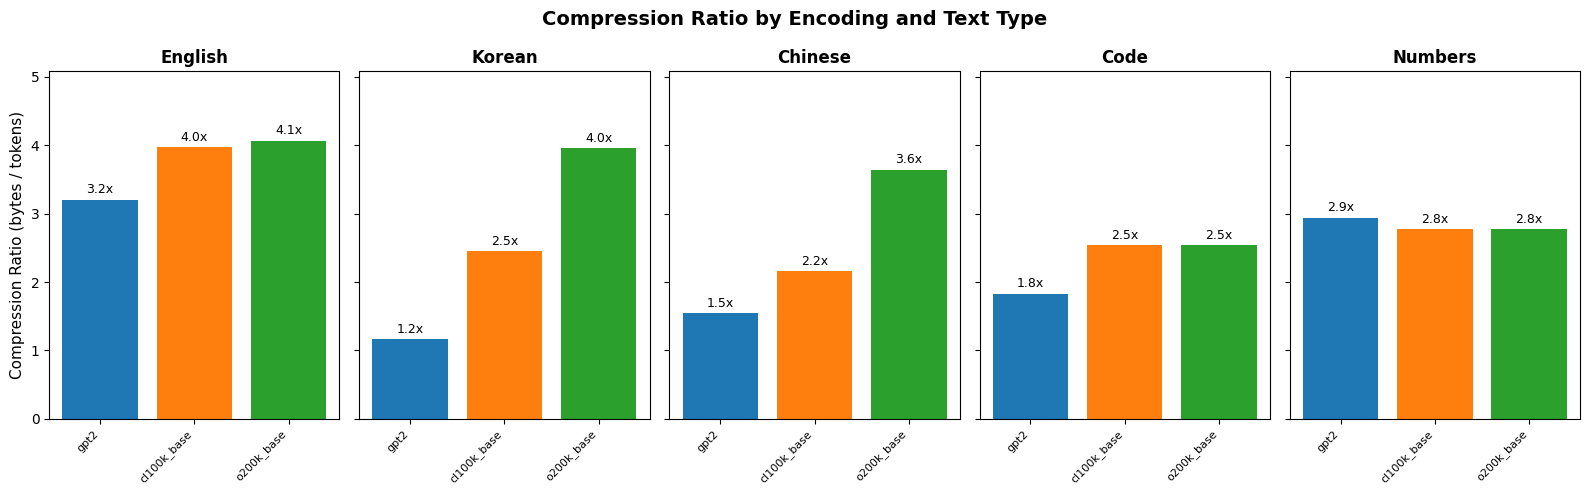

In [31]:
# Visualize compression ratios
fig, axes = plt.subplots(1, len(test_texts), figsize=(16, 5), sharey=True)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
enc_names = list(enc_subset.keys())

for ax, (text_name, ratios) in zip(axes, ratios_by_text.items()):
    ratio_values = [ratios[name] for name in enc_names]
    bars = ax.bar(range(len(enc_names)), ratio_values, color=colors)
    ax.set_title(text_name, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(enc_names)))
    ax.set_xticklabels(enc_names, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, max(max(r.values()) for r in ratios_by_text.values()) * 1.25)
    for bar, ratio in zip(bars, ratio_values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{ratio:.1f}x", ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("Compression Ratio (bytes / tokens)", fontsize=11)
fig.suptitle("Compression Ratio by Encoding and Text Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Several patterns emerge:

1. **English text** — compression improves modestly with larger vocab. English was always well-served, even by GPT-2's tokenizer.
2. **Korean and Chinese** — dramatic improvement from GPT-2 to later encodings. GPT-2 was trained predominantly on English text, so its merges poorly represent CJK characters. Later tokenizers were trained on more multilingual data and learned much better subword units for these scripts.
3. **Code** — all encoders handle code reasonably well because it's mostly ASCII, but newer encodings pick up common code patterns (indentation, keywords) more efficiently.
4. **Numbers** — the GPT-4 3-digit grouping (from the improved regex pattern) means numbers get split more consistently.

## The Vocabulary Size Tradeoff

Why not just make the vocabulary as large as possible? Because the **embedding table** has `vocab_size × d_model` parameters, and the **output projection** (language model head) has the same size. Doubling the vocab doubles both of these.

In [32]:
# Embedding table size for various models
configs = [
    ("Our lesson 7 GPT", 65, 384),
    ("GPT-2 (124M)", 50_257, 768),
    ("GPT-4 (est.)", 100_277, 12_288),
    ("LLaMA-2 7B", 32_000, 4_096),
    ("LLaMA-3 8B", 128_256, 4_096),
]

print(f"{'Model':<22s} {'Vocab':>10s} {'d_model':>8s} {'Embed Params':>14s} {'Size (fp16)':>12s}")
print("-" * 70)
for name, vocab, d_model in configs:
    params = vocab * d_model
    size_mb = params * 2 / (1024 ** 2)  # 2 bytes per fp16 parameter
    print(f"{name:<22s} {vocab:>10,} {d_model:>8,} {params:>14,} {size_mb:>10.1f} MB")

Model                       Vocab  d_model   Embed Params  Size (fp16)
----------------------------------------------------------------------
Our lesson 7 GPT               65      384         24,960        0.0 MB
GPT-2 (124M)               50,257      768     38,597,376       73.6 MB
GPT-4 (est.)              100,277   12,288  1,232,203,776     2350.2 MB
LLaMA-2 7B                 32,000    4,096    131,072,000      250.0 MB
LLaMA-3 8B                128,256    4,096    525,336,576     1002.0 MB


LLaMA-3 jumped from 32K to 128K vocabulary — adding roughly 400M embedding parameters to the 8B model. Meta determined this was worth it because shorter sequences (especially for non-English languages) more than compensated in inference efficiency. The key lesson: **vocabulary size is a system-level optimization**, not just a compression metric. It affects model size, training cost, inference speed, multilingual performance, and context window utilization.

## sentencepiece — The Alternative Approach

While `tiktoken` (OpenAI) operates on **UTF-8 bytes**, `sentencepiece` (Google, used by LLaMA, Mistral, T5) can operate on either bytes or **Unicode code points**. The byte-level approach is simpler and universally applicable. The code-point approach can be more efficient for languages where a single character takes 3 UTF-8 bytes (like Korean or Chinese) — instead of starting with 3 tokens per character, you start with 1.

Both implement BPE at their core; the difference is what they consider the "base symbols" before merging begins.

# Section 7: Tokenization Gotchas — Why LLMs Do Weird Things

This is arguably the most practically important section. Many behaviors that people attribute to LLMs "being dumb" are actually **tokenization artifacts**. The model isn't failing at reasoning — it literally cannot see the information it would need because the tokenizer has already compressed it away.

Understanding these gotchas is essential for:
- **Prompt engineering** — knowing how to format input for best results
- **Evaluating models** — distinguishing tokenization limitations from model limitations
- **Building applications** — knowing what tasks are fundamentally hard for any LLM

Let's trace several famous failure modes back to their tokenization roots.

## Gotcha 1: Why LLMs Can't Spell

LLMs famously struggle with character-level tasks like "how many r's in strawberry?" This isn't a reasoning failure — the model **literally never sees individual characters**. It sees tokens, and tokens can span multiple characters.

In [33]:
# The model doesn't see characters — it sees tokens
enc = tiktoken.get_encoding("cl100k_base")

words = ["strawberry", "Mississippi", "assessment", "accommodation", "hello"]
for word in words:
    tokens = enc.encode(word)
    token_strs = [enc.decode([t]) for t in tokens]
    print(f"'{word}' ({len(word)} chars) -> {len(tokens)} tokens: {token_strs}")

'strawberry' (10 chars) -> 3 tokens: ['str', 'aw', 'berry']
'Mississippi' (11 chars) -> 2 tokens: ['Miss', 'issippi']
'assessment' (10 chars) -> 1 tokens: ['assessment']
'accommodation' (13 chars) -> 2 tokens: ['accom', 'modation']
'hello' (5 chars) -> 1 tokens: ['hello']


When asked "how many r's in strawberry?", the model sees something like `['str', 'aw', 'berry']` — three opaque tokens. To answer correctly, it would need to mentally decompose each token back into individual characters, count the r's in each piece, and sum them up. This is a skill the model was never explicitly trained on.

**The workaround:** ask the model to spell the word out letter by letter first (chain-of-thought at the character level). This forces it to produce one token per character, making counting possible. Modern models (GPT-4o, Claude 3.5+) have improved at this, but it remains a fundamentally harder task than it appears.

## Gotcha 2: Why Arithmetic Is Hard

Numbers tokenize **inconsistently**. The same digits get grouped into different tokens depending on the surrounding context, the specific number, and which tokenizer is used. Without consistent digit-level representations, the model cannot learn a clean algorithm for operations like addition with carrying.

In [34]:
# Numbers tokenize inconsistently
enc_gpt2 = tiktoken.get_encoding("gpt2")
enc_gpt4 = tiktoken.get_encoding("cl100k_base")

number_texts = ["127", "128", "1000", "12345", "99999", "127 + 983", "3.14159"]

print(f"{'Text':<15s} {'GPT-2 tokens':<30s} {'GPT-4 tokens':<30s}")
print("-" * 75)
for text in number_texts:
    gpt2_toks = [enc_gpt2.decode([t]) for t in enc_gpt2.encode(text)]
    gpt4_toks = [enc_gpt4.decode([t]) for t in enc_gpt4.encode(text)]
    print(f"{text:<15s} {str(gpt2_toks):<30s} {str(gpt4_toks):<30s}")

Text            GPT-2 tokens                   GPT-4 tokens                  
---------------------------------------------------------------------------
127             ['127']                        ['127']                       
128             ['128']                        ['128']                       
1000            ['1000']                       ['100', '0']                  
12345           ['123', '45']                  ['123', '45']                 
99999           ['99', '999']                  ['999', '99']                 
127 + 983       ['127', ' +', ' 9', '83']      ['127', ' +', ' ', '983']     
3.14159         ['3', '.', '14', '159']        ['3', '.', '141', '59']       


Notice the inconsistencies: `1000` is a single token in GPT-2 but gets split into `['100', '0']` in GPT-4. The grouping of `99999` is completely different between the two — `['99', '999']` vs `['999', '99']`. Even `3.14159` splits at different digit boundaries. Whether digits get grouped as `1`+`27` or `12`+`7` depends entirely on which number sequences were common in the training data.

This is why LLMs struggle with arithmetic on large numbers. The carry operation in addition requires digit-level alignment, but the tokenizer doesn't preserve digit boundaries.

## Gotcha 3: The Multilingual Tax

Non-English languages use **significantly more tokens** for the same semantic content. This isn't just about UTF-8 byte lengths — it's about whether the tokenizer learned good merges for that language's character patterns. The consequences are real and measurable.

In [35]:
# Same approximate meaning, very different token counts
enc_gpt2 = tiktoken.get_encoding("gpt2")
enc_gpt4 = tiktoken.get_encoding("cl100k_base")

translations = [
    ("English",  "Hello, how are you today? The weather is beautiful and I want to go for a walk in the park."),
    ("Spanish",  "Hola, \u00bfc\u00f3mo est\u00e1s hoy? El clima es hermoso y quiero ir a caminar por el parque."),
    ("Korean",   "\uc548\ub155\ud558\uc138\uc694, \uc624\ub298 \uc5b4\ub5a0\uc138\uc694? \ub0a0\uc528\uac00 \uc544\ub984\ub2f5\uace0 \uacf5\uc6d0\uc5d0\uc11c \uc0b0\ucc45\ud558\uace0 \uc2f6\uc5b4\uc694."),
    ("Chinese",  "\u4f60\u597d\uff0c\u4eca\u5929\u8fc7\u5f97\u600e\u4e48\u6837\uff1f\u5929\u6c14\u5f88\u7f8e\uff0c\u6211\u60f3\u53bb\u516c\u56ed\u6563\u6b65\u3002"),
    ("Arabic",   "\u0645\u0631\u062d\u0628\u0627\u060c \u0643\u064a\u0641 \u062d\u0627\u0644\u0643 \u0627\u0644\u064a\u0648\u0645\u061f \u0627\u0644\u0637\u0642\u0633 \u062c\u0645\u064a\u0644 \u0648\u0623\u0631\u064a\u062f \u0627\u0644\u0645\u0634\u064a \u0641\u064a \u0627\u0644\u062d\u062f\u064a\u0642\u0629."),
    ("Hindi",    "\u0928\u092e\u0938\u094d\u0924\u0947, \u0906\u091c \u0906\u092a \u0915\u0948\u0938\u0947 \u0939\u0948\u0902? \u092e\u094c\u0938\u092e \u0905\u091a\u094d\u091b\u093e \u0939\u0948 \u0914\u0930 \u092e\u0948\u0902 \u092a\u093e\u0930\u094d\u0915 \u092e\u0947\u0902 \u0938\u0948\u0930 \u0915\u0930\u0928\u093e \u091a\u093e\u0939\u0924\u093e \u0939\u0942\u0902\u0964"),
    ("Japanese", "\u3053\u3093\u306b\u3061\u306f\u3001\u4eca\u65e5\u306f\u304a\u5143\u6c17\u3067\u3059\u304b\uff1f\u5929\u6c17\u304c\u7f8e\u3057\u304f\u3066\u516c\u5712\u3092\u6563\u6b69\u3057\u305f\u3044\u3067\u3059\u3002"),
]

# Get English baseline counts
en_gpt2 = len(enc_gpt2.encode(translations[0][1]))
en_gpt4 = len(enc_gpt4.encode(translations[0][1]))

print(f"{'Language':<10s} {'GPT-2':>8s} {'vs EN':>7s}  {'GPT-4':>8s} {'vs EN':>7s}  {'Improvement':>12s}")
print("-" * 62)
for lang, text in translations:
    n_gpt2 = len(enc_gpt2.encode(text))
    n_gpt4 = len(enc_gpt4.encode(text))
    ratio_gpt2 = n_gpt2 / en_gpt2
    ratio_gpt4 = n_gpt4 / en_gpt4
    improvement = (1 - n_gpt4/n_gpt2) * 100 if n_gpt2 > 0 else 0
    print(f"{lang:<10s} {n_gpt2:>8d} {ratio_gpt2:>6.1f}x  {n_gpt4:>8d} {ratio_gpt4:>6.1f}x  {improvement:>10.0f}% fewer")

Language      GPT-2   vs EN     GPT-4   vs EN   Improvement
--------------------------------------------------------------
English          23    1.0x        23    1.0x           0% fewer
Spanish          34    1.5x        27    1.2x          21% fewer
Korean           88    3.8x        44    1.9x          50% fewer
Chinese          49    2.1x        30    1.3x          39% fewer
Arabic           58    2.5x        40    1.7x          31% fewer
Hindi           111    4.8x        74    3.2x          33% fewer
Japanese         49    2.1x        30    1.3x          39% fewer


The consequences of this "multilingual tax" are significant:

1. **Context window** — a 128K token context window holds far less content in Korean or Hindi than in English. The same document that fits comfortably in English might get truncated in another language.
2. **API costs** — pricing is per-token, so non-English users pay more for the same semantic content.
3. **"Thinking time"** — each Transformer layer processes one token per position. More tokens for the same content means the model has to spread its computation thinner, potentially reducing the quality of reasoning per concept.

GPT-4's tokenizer (trained on more multilingual data) significantly reduced this gap, but it hasn't eliminated it. This is a fundamental equity issue in LLM design that the field is actively working on.

## Gotcha 4: Trailing Whitespace

A subtle but practically important quirk: adding a space at the end of your prompt changes the tokenization in a way that can affect model output.

In [36]:
# Trailing whitespace changes tokenization
enc = tiktoken.get_encoding("cl100k_base")

prompts = [
    "Hello world",
    "Hello world ",
    "Hello world  ",
]

for prompt in prompts:
    tokens = enc.encode(prompt)
    decoded = [repr(enc.decode([t])) for t in tokens]
    print(f"{repr(prompt):25s} -> {decoded}")

'Hello world'             -> ["'Hello'", "' world'"]
'Hello world '            -> ["'Hello'", "' world'", "' '"]
'Hello world  '           -> ["'Hello'", "' world'", "'  '"]


In BPE tokenizers, spaces typically merge with the **following** word — `" Hello"` is one token, not `"Hello"` + `" "`. When you add a trailing space, it becomes a standalone space token. This is an unusual token in the model's experience (spaces almost always precede a word), so it can push the model into unexpected behavior — like continuing with an unusual formatting pattern or producing extra whitespace.

**Takeaway:** be mindful of trailing whitespace in your prompts. Most API clients strip it, but if you're building raw API integrations, this can be a subtle source of inconsistent behavior.

## Gotcha 5: Implications for Prompt Engineering

These tokenization quirks have practical implications for how you interact with LLMs:

1. **Character-level tasks** — if you need a model to count characters or do letter-level operations, ask it to spell the word out first (`s-t-r-a-w-b-e-r-r-y`) to force character-level tokens
2. **Arithmetic formatting** — adding spaces between digits (`1 2 7 + 9 8 3`) forces each digit to be its own token, giving the model a fighting chance at digit-level operations
3. **Trailing whitespace** — avoid it; it wastes a token and creates an unusual token boundary
4. **Non-English context limits** — be aware that your "128K token context window" holds less content in Korean, Arabic, or Hindi than in English
5. **Token-aware prompting** — understanding tokenization helps you write prompts that align with token boundaries rather than fighting against them

In [37]:
# The digit-spacing trick for arithmetic
enc = tiktoken.get_encoding("cl100k_base")

# Normal formatting
normal = "127 + 983"
tokens_normal = [enc.decode([t]) for t in enc.encode(normal)]

# Spaced digits
spaced = "1 2 7 + 9 8 3"
tokens_spaced = [enc.decode([t]) for t in enc.encode(spaced)]

print("Normal formatting:")
print(f"  '{normal}' -> {tokens_normal}")
print(f"  The model sees '{normal}' as {len(tokens_normal)} tokens — digits are NOT individually accessible")
print()
print("Spaced digits:")
print(f"  '{spaced}' -> {tokens_spaced}")
print(f"  The model sees '{spaced}' as {len(tokens_spaced)} tokens — each digit is its own token")

Normal formatting:
  '127 + 983' -> ['127', ' +', ' ', '983']
  The model sees '127 + 983' as 4 tokens — digits are NOT individually accessible

Spaced digits:
  '1 2 7 + 9 8 3' -> ['1', ' ', '2', ' ', '7', ' +', ' ', '9', ' ', '8', ' ', '3']
  The model sees '1 2 7 + 9 8 3' as 12 tokens — each digit is its own token


# Conclusion

We built a complete BPE tokenizer from scratch, incrementally improving it as we discovered limitations at each stage:

| Step | What We Built | Problem It Solved | Limitation Discovered |
| :--- | :--- | :--- | :--- |
| 1 | **Character-level tokenizer** (lesson 7) | Simple, lossless for known chars | Crashes on unknown chars, very long sequences |
| 2 | **Raw byte tokenization** (UTF-8) | Universal coverage — any text, any language | Even longer sequences (1 token per byte) |
| 3 | **BasicTokenizer** (BPE on bytes) | Compresses common patterns, shorter sequences | Merges cross word boundaries — meaningless tokens |
| 4 | **RegexTokenizer** (GPT-2 pattern) | Pre-tokenization prevents cross-boundary merges | Case-sensitive contractions, numbers as one chunk |
| 5 | **RegexTokenizer** (GPT-4 pattern) | Case-insensitive contractions, 1–3 digit groups | No way to handle reserved control tokens |
| 6 | **Special token support** | `<\|endoftext\|>` and friends as atomic tokens | Production-ready architecture |

With tokenization understood, we now have the **complete picture** of how text goes from characters to model predictions:

$$\text{raw text} \xrightarrow{\text{tokenizer}} \text{token IDs} \xrightarrow{\text{embedding}} \text{vectors} \xrightarrow{\text{Transformer}} \text{output probabilities}$$

In lesson 7 we built everything from the embedding lookup onward. In this lesson we built the piece that comes **before** it — the critical preprocessing step that determines what the model actually sees.

## Further Reading

- **"Neural Machine Translation of Rare Words with Subword Units"** ([Sennrich et al., 2016](https://arxiv.org/abs/1508.07909)) — the paper that adapted BPE for NLP tokenization
- **"Language Models are Unsupervised Multitask Learners"** ([Radford et al., 2019](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)) — the GPT-2 paper, which introduced regex-based pre-tokenization for BPE
- **Karpathy's minbpe** — [github.com/karpathy/minbpe](https://github.com/karpathy/minbpe) — minimal BPE implementation that this lesson is based on
- **tiktoken** — [github.com/openai/tiktoken](https://github.com/openai/tiktoken) — OpenAI's fast Rust-based production tokenizer
- **sentencepiece** — [github.com/google/sentencepiece](https://github.com/google/sentencepiece) — Google's tokenizer used by LLaMA, Mistral, and T5
- **Hugging Face Tokenizers** — [github.com/huggingface/tokenizers](https://github.com/huggingface/tokenizers) — fast implementation with Python bindings
- **tiktokenizer** — [tiktokenizer.vercel.app](https://tiktokenizer.vercel.app) — interactive web tool for visualizing how tiktoken tokenizes text